# Laboratorio
<img src="./archivos/Imagenes/logo_UTN.svg" align="right" width="150" />



## Plantilla

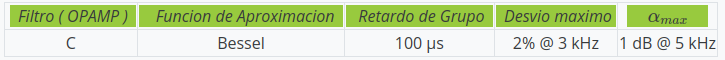

Primero se calcula la frecuencia de normalizacion: 

$$\Omega_{\omega} = \frac{D_{n}(0)}{D(0)} \frac{rad}{s} \quad y \quad D(0) = 100 \micro s \quad \implies \quad \Omega_{\omega} = \frac{1 s}{100 \micro s} \frac{rad}{s} = 10 k \frac{rad}{s} \quad \implies \quad \boxed{\Omega_{\omega} = 10 k \frac{rad}{s}}$$

$$ \Omega_P = \frac{\omega_P}{\Omega_{\omega}} = \frac{2·\pi·5kH_z}{10 k\frac{rad}{s}} = \pi $$

In [2]:
#Librerias Externas
from scipy import signal

#Libreria TC2
from pytc2.sistemas_lineales import pretty_print_lti

#  Bessel-Thompson de orden 2, 3 y 4

# Bessel-Thompson de orden 2
z2,p2 = signal.bessel(2, Wn=1, btype='low', analog=True, norm='delay')
print("Bessel-Thompson de orden 2:")
pretty_print_lti(z2,p2)

# Bessel-Thompson de orden 3
z3,p3 = signal.bessel(3, Wn=1, btype='low', analog=True, norm='delay')
print("Bessel-Thompson de orden 3:")
pretty_print_lti(z3,p3)

# Bessel-Thompson de orden 4
z4,p4 = signal.bessel(4, Wn=1, btype='low', analog=True, norm='delay')
print("Bessel-Thompson de orden 4:")
pretty_print_lti(z4,p4)


Bessel-Thompson de orden 2:


<IPython.core.display.Math object>

Bessel-Thompson de orden 3:


<IPython.core.display.Math object>

Bessel-Thompson de orden 4:


<IPython.core.display.Math object>

## 2)Elegir la T(S) con el mínimo orden que cumple con alpha max = 1 dB

- Por iteracion encontramos que el orden del filtro debe ser 4:

$$ \boxed{T(S) = \frac{105}{S^4 + 10 · S^3 + 45 · S^2 + 105 · S + 105}} $$


## 3) Sintetizar el circuito normalizado con estructuras Ackerberg-Mosberg

Transferencia de orden 4 (SOS) normalizada:

$$\boxed{T(S) = \frac{9.140}{S^2 + 5.792 S + 9.140}·\frac{11.488}{S^2 + 4.208 S + 11.488}}$$

Para sintetizar este circuito se utilizaran dos etapas Akerberg-Mosberg 

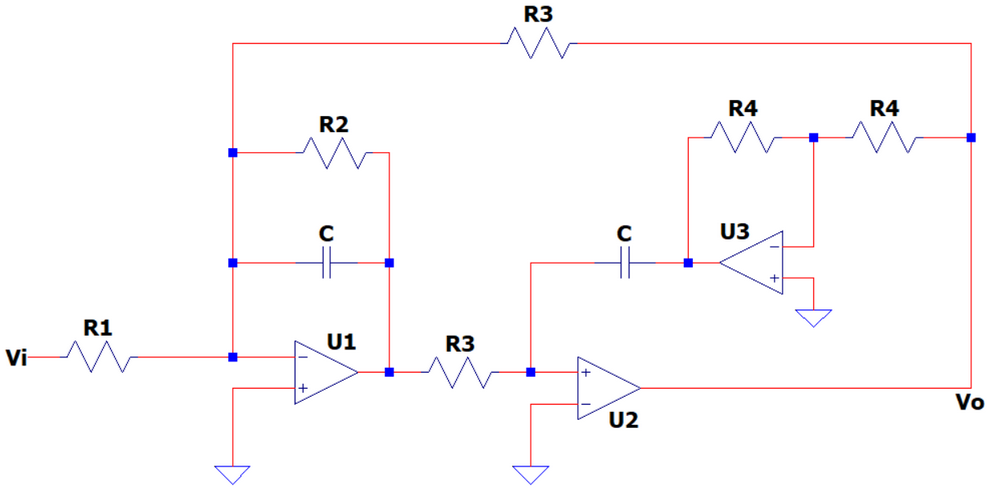

Transferencia del circuito Akerberg-Mosberg:
$$T(S) = -\frac{K\omega_{0}^{2}}{S^{2}+\frac{\omega_{0}}{Q}S+\omega_{0}^{2}} \quad y \quad \omega_{0} = \frac{1}{R_{3}C} \quad y \quad Q = \frac{R_{2}}{R_{3}} \quad y \quad K = \frac{R_{3}}{R_{1}}$$

Como para el orden 4 no cumplia con con la atenuacion maxima de 1dB a $5kH_z$, se le asigno un K = 1.5 a cada etapa.

### 1er Etapa de segundo orden de la transferencia:

$$ T_1(S) = \frac{9.140}{S^2 + 5.792 S + 9.140} \quad \implies \quad \omega_{0}^{2} = 9.140 \quad y \quad \frac{\omega_{0}}{Q} = 5.792 \quad y \quad K = 1.5 $$

$$ K = \frac{R_{31}}{R_{11}} = 1.5 \quad \implies \quad  R_{31} = 1.5 R_{11} \quad y \quad \omega_0 = \sqrt{9.140} = 3.023 \quad \implies \quad \omega_0 = \frac{1}{R_{31}C_1} = 3.023 \quad y \quad \frac{\omega_0}{Q} = \frac{1}{R_{31}C_1} \frac{1}{\frac{R_{21}}{R_{31}}} = \frac{1}{R_{21}C_1} = 5.792$$

$$\boxed{R_{31} = 1.5 R_{11} \quad y \quad \frac{1}{R_{31}C_1} = 3.023 \quad y \quad \frac{1}{R_{21}C_1} = 5.792}$$

- Se adopta $C_1 = 1$, entonces:

$$\frac{1}{R_{31}} = 3.023 \quad \implies \boxed{\quad R_{31} = \frac{1}{3.023} = 0.331} \quad y \quad \boxed{R_{11} = \frac{R_{31}}{1.5} = 0.221} \quad y \quad \frac{1}{R_{21}} = 5.792 \quad \implies \quad \boxed{R_{21} = \frac{1}{5.792} = 0.173}$$

### 2da Etapa de segundo orden de la transferencia:

$$ T_2(S) = \frac{11.488}{S^2 + 4.208 S + 11.488} \quad \implies \quad \omega_{0}^{2} = 11.488 \quad y \quad \frac{\omega_{0}}{Q} = 4.208 \quad y \quad K = 1.5 $$

$$ K = \frac{R_{32}}{R_{12}} = 1 \quad \implies \quad  R_{32} = 1.5 R_{12} \quad y \quad \omega_0 = \sqrt{11.488} = 3.389 \quad \implies \quad \omega_0 = \frac{1}{R_{32}C_2} = 3.389 \quad y \quad \frac{\omega_0}{Q} = \frac{1}{R_{32}C_2} \frac{1}{\frac{R_{22}}{R_{32}}} = \frac{1}{R_{22}C_2} = 4.208$$

$$\boxed{R_{32} = 1.5 R_{12} \quad y \quad \frac{1}{R_{32}C_2} = 3.389 \quad y \quad \frac{1}{R_{22}C_2} = 4.208}$$

- Se adopta $C_2 = 1$, entonces:

$$\frac{1}{R_{32}} = 3.389 \quad \implies \quad \boxed{R_{32} = \frac{1}{3.389} = 0.295} \quad \implies \quad \boxed{R_{12} = \frac{R_{32}}{1.5} = 0.197} \quad y \quad \frac{1}{R_{22}} = 4.208 \quad \implies \quad \boxed{R_{22} = \frac{1}{4.208} = 0.238}$$

## 4) Desnormalizacion de los componentes:

- Se adopta una norma de impedancia de $\Omega_z = 10 k\ohm$
- La norma de frecuencia es $\Omega_{\omega} = 10 k\frac{rad}{s}$
- Desnormalización de resistencias: $R = R_n · \Omega_z$
- Desnormalización de capacitores: $C = \frac{1}{\Omega_z · \Omega_{\omega} · C_n}$

### Valores de los componentes para la primer etapa:

- Resistencias:

$$ R_{11} = 0.221 · 10 k\ohm = 2.21 k\ohm \quad ; \quad R_{21} = 0.173 · 10 k\ohm = 1.73 k\ohm \quad ; \quad R_{31} = 0.331 · 10 k\ohm = 3.31 k\ohm $$

- Capacitores:

$$ C_1 = \frac{1}{10 k\ohm · 10 k\frac{rad}{s} · 1} = 10 nf $$

### Valores de los componentes para la segunda etapa:

- Resistencias:

$$ R_{12} = 0.197 · 10 k\ohm = 1.97 k\ohm \quad ; \quad R_{22} = 0.238 · 10 k\ohm = 2.38 k\ohm \quad ; \quad R_{32} = 0.295 · 10 k\ohm = 2.95 k\ohm $$

- Capacitores:

$$ C_2 = \frac{1}{10 k\ohm · 10 k\frac{rad}{s} · 1} = 10 nf $$

### Valores de Componentes Calculados

$$ \boxed{R_{11} = 2.21 k\ohm} \quad ; \quad \boxed{R_{21} = 1.73 k\ohm} \quad ; \quad \boxed{R_{31} = 3.31 k\ohm} \quad ; \quad \boxed{C_1 = 10 nf} $$
$$ \boxed{R_{12} = 1.97 k\ohm} \quad ; \quad \boxed{R_{22} = 2.38 k\ohm} \quad ; \quad \boxed{R_{32} = 2.95 k\ohm} \quad ; \quad \boxed{C_2 = 10 nf} $$

### Valores de Componentes Comerciales Adoptados

$$ \boxed{R_{11} = 2.2 k\ohm} \quad ; \quad \boxed{R_{21} = 1.8 k\ohm} \quad ; \quad \boxed{R_{31} = 3.3 k\ohm} \quad ; \quad \boxed{C_1 = 10 nf} $$
$$ \boxed{R_{12} = 1.8 k\ohm + 220 \ohm} \quad ; \quad \boxed{R_{22} = 2.2 k\ohm + 220 \ohm} \quad ; \quad \boxed{R_{32} = 2.7 k\ohm + 330 \ohm} \quad ; \quad \boxed{C_2 = 10 nf} $$

Se adopta $\boxed{R_{41} = R_{42} = 1kohm}$

## 5) Simulacion del circuito

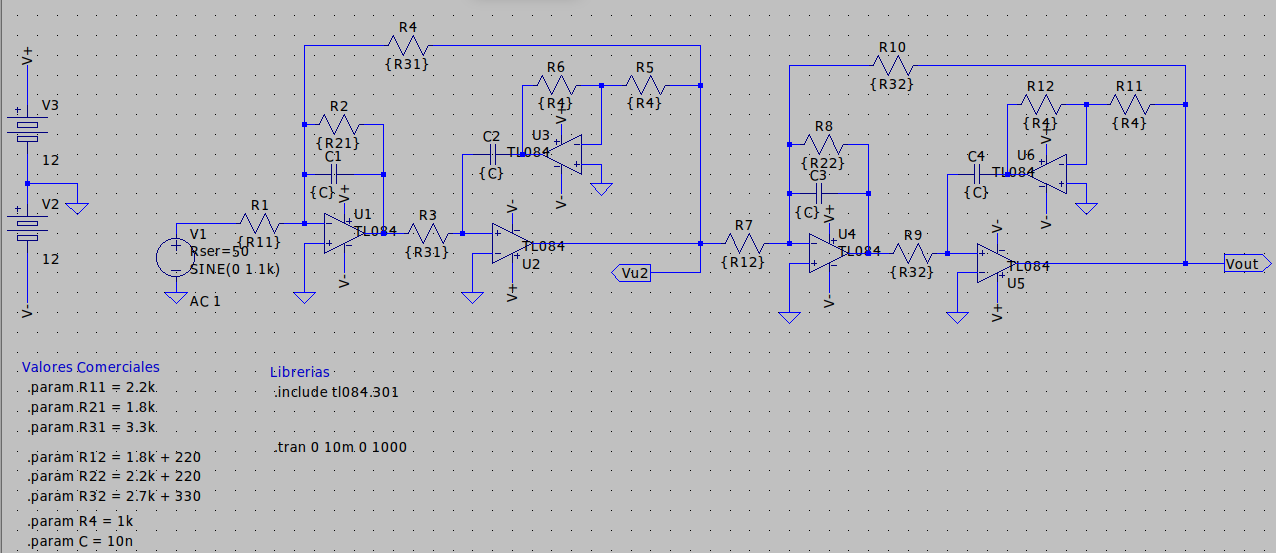

- ### Respuesta Temporal ($v_i(t) = 1V · Sen(2·\pi·1k·t)$):

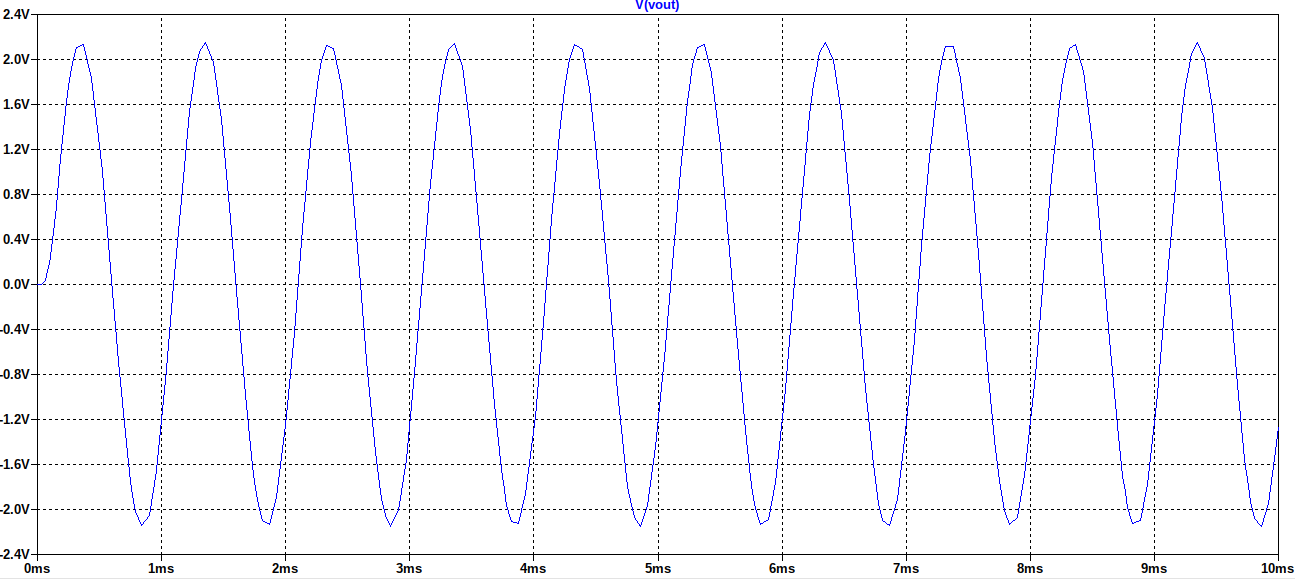

- ### Respuesta en frecuencia:

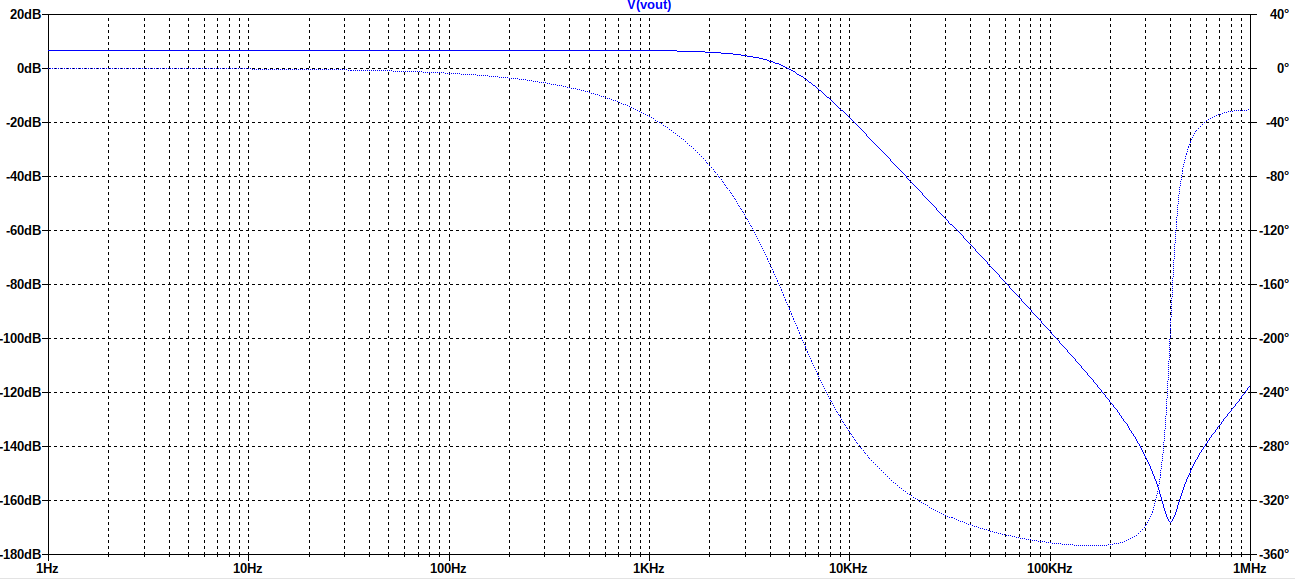

## 6) Respuesta Temporal

#### Respuesta ante una entrada de $v_i(t) = 1V · Sen(2·\pi·1k·t)$

- Entrada canal 1 (amarillo), salida canal 2 (celeste)

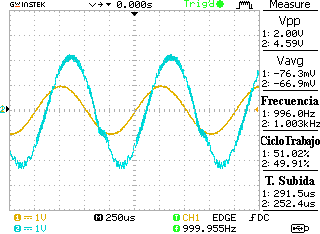

#### Respuesta ante una entrada de $v_i(t) = 1V · Sen(2·\pi·3k·t)$

- Entrada canal 1 (amarillo), salida canal 2 (celeste)

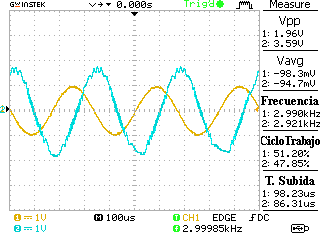

#### Respuesta ante una entrada de $v_i(t) = 1V · Sen(2·\pi·5k·t)$

- Entrada canal 1 (amarillo), salida canal 2 (celeste)

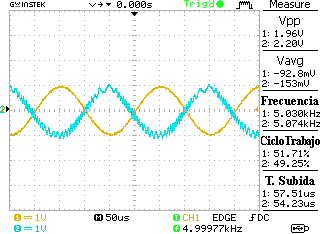

#### Respuesta ante una entrada de $v_i(t) = 1V · Sen(2·\pi·10k·t)$

- Entrada canal 1 (amarillo), salida canal 2 (celeste)

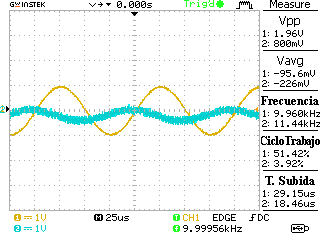